In [182]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split

In [183]:
df = pd.read_csv('loan_approval_data.csv')

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Handling MIssing value


In [185]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns


In [186]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

using Simpleimputet which replacing missing value using a descriptive statistic(mean,median,mode)

In [187]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy= "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [188]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [189]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] =  cat_imp.fit_transform(df[categorical_cols])

EDA

Text(0.5, 1.0, 'is loan approved or not')

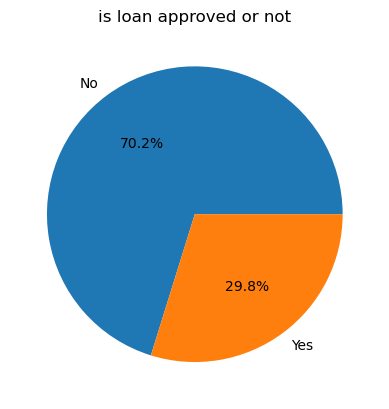

In [190]:
# How balance our classes are

classes_count  = df["Loan_Approved"].value_counts()

plt.pie(classes_count , labels = ["No", "Yes"], autopct= "%1.1f%%")
plt.title("is loan approved or not")

[Text(0, 0, '621'), Text(0, 0, '379')]

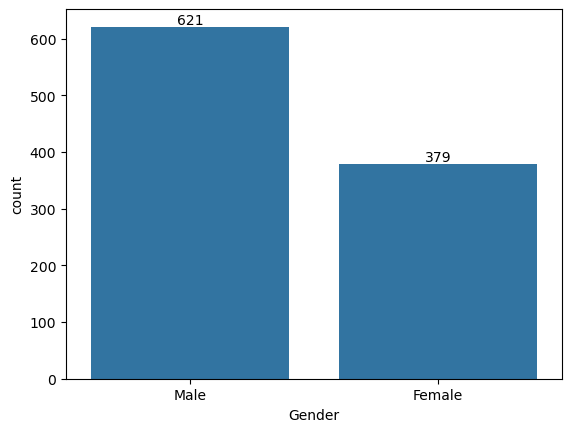

In [191]:
# other categorical input
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

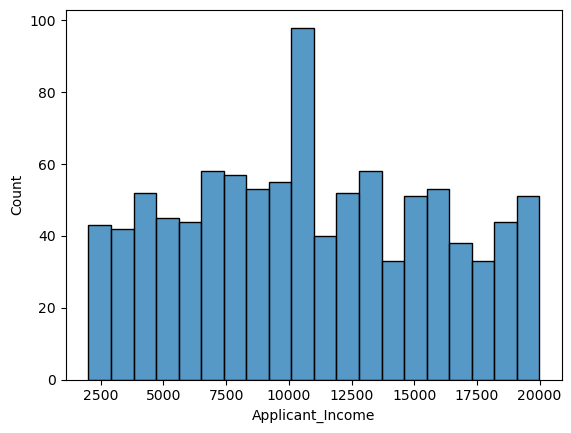

In [192]:
# analyze  income
sns.histplot(
    data = df,
    x  = "Applicant_Income",
    bins =20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

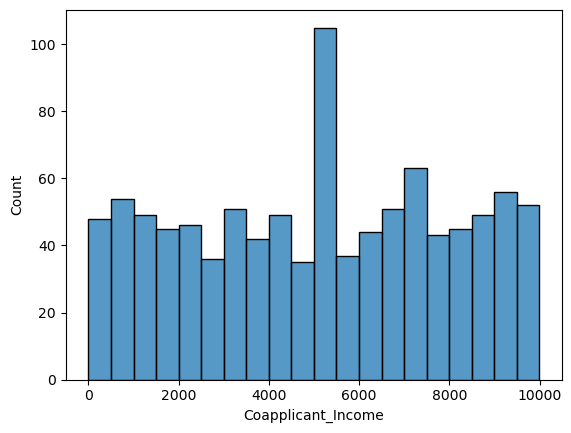

In [193]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins =20
)

outlier detection


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

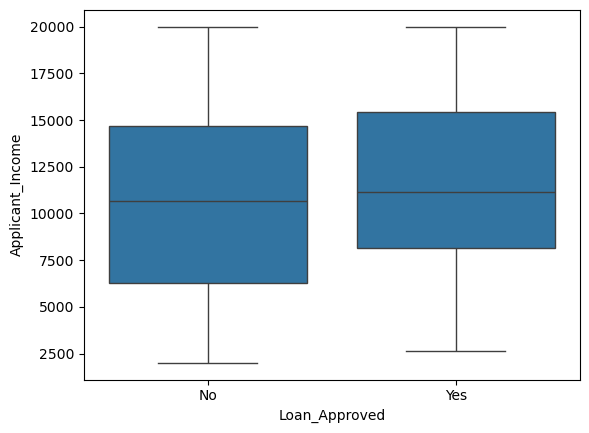

In [194]:
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    
    y = "Applicant_Income"
)

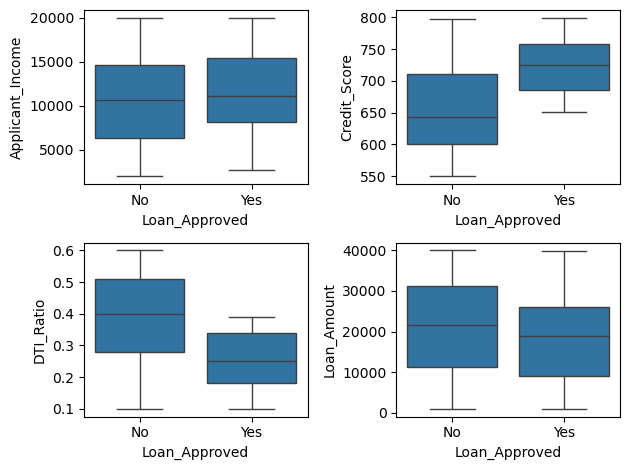

In [195]:
fig ,axes = plt.subplots(2,2)

sns.boxplot(ax =axes[0,0],data =df , x = "Loan_Approved", y ="Applicant_Income")
sns.boxplot(ax =axes[0,1] ,data =df , x = "Loan_Approved", y ="Credit_Score" )
sns.boxplot(ax =axes[1,0] ,data =df , x = "Loan_Approved", y ="DTI_Ratio" )
sns.boxplot(ax =axes[1,1] ,data =df , x = "Loan_Approved", y ="Loan_Amount" )
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

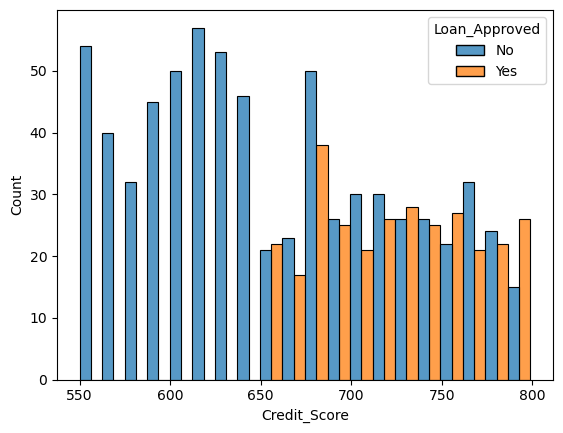

In [196]:
# credit score with loan approved
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins =20,
    multiple= "dodge"
    )

<Axes: xlabel='Applicant_Income', ylabel='Count'>

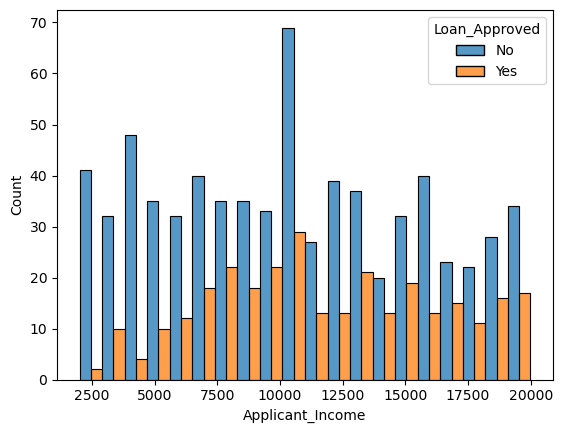

In [197]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    bins =20,
    multiple= "dodge"
    )

In [198]:
# Remove Applicantid as it has no role for target
df  =df.drop("Applicant_ID", axis=1)

feature encoding


In [199]:
# label encoder
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df['Loan_Approved'] = le.fit_transform(df["Loan_Approved"])

In [200]:
df["Gender"] = df["Gender"].map({"Male" :1 , "Female" : 0})

In [201]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,0,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,1,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,0,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,0,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,1,Private,1


In [202]:
cols = ["Employment_Status","Marital_Status","Loan_Approved","Loan_Purpose","Property_Area","Employer_Category"]

#df = pd.get_dummies(df,columns = cols,drop_first = True )
ohe = OneHotEncoder(drop = "first", sparse_output = False , handle_unknown = "ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(cols) ,index = df.index)
df = pd.concat([df.drop(columns = cols),encoded_df] , axis =1)

In [203]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Gender,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Approved_1,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,0,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,0,1,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Gender               

coreletion heatmap: check linear reletionship

it is visual representation of the reletionships between numerical variables in a dataset

it shows cooreletion coefficient (r) between two numeric variables

. ranges ranges from 0 to 1
. 1 is perfect positive coreletion
.  -1 is perfect negetive co reletion
. 0 is no linear co reletion

if x1 increses and x2 also increses it is +ve coreletion 

if x1 increses and x2 decreses then it is -ve coreletion


In [205]:
print(df.columns.tolist())

['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level', 'Gender', 'Employment_Status_Salaried', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Marital_Status_Single', 'Loan_Approved_1', 'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Employer_Category_Government', 'Employer_Category_MNC', 'Employer_Category_Private', 'Employer_Category_Unemployed']


<Axes: >

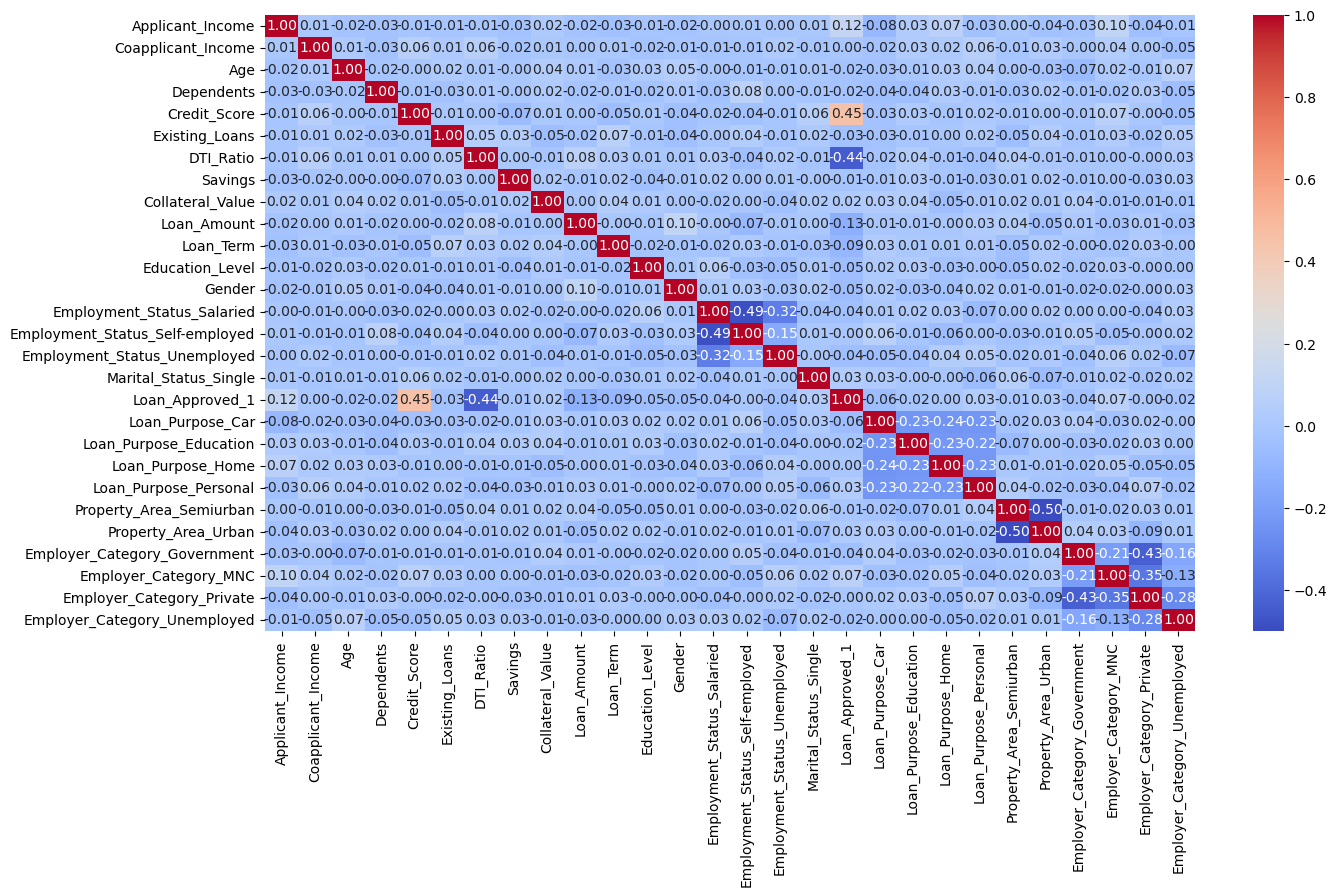

In [206]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (15,8))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

here we wrote Loan_Approved_1 bcz we did one hot encoding before it

In [207]:
num_cols.corr()["Loan_Approved_1"].sort_values(ascending = False)

Loan_Approved_1                    1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

 correletion heatmap helps us to find :
 quick insights,
 detect multicolinearity,
 data exploration .

Train-Test-Split + Feature Scalling

In [208]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [209]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state =42)

In [210]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)

X_test = scaler.transform(x_test)

In [211]:
X_test

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.50390326,
        -0.41388776,  1.16316   ],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.50390326,
        -0.41388776,  1.16316   ],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.50390326,
        -0.41388776,  1.16316   ],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.50390326,
        -0.41388776,  1.16316   ],
       [-0.37650705, -0.97825874, -0.54802752, ...,  1.9845079 ,
        -0.41388776, -0.85972695],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.50390326,
        -0.41388776,  1.16316   ]])

Train and Evaluation model


In [212]:
# logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train,y_train)

y_pred = log_model.predict(X_test)

In [213]:
# knn classifer
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [214]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

In [215]:
# evaluation
from sklearn.metrics import classification_report
models = {'LogisticRegression' : log_model , "knn" : knn , "Naive Bayes" : nb}

for name,model in models.items():
    y_pred = model.predict(x_test)
    print(name)
    print(f"classification report = {classification_report(y_test,y_pred)}")






LogisticRegression
classification report =               precision    recall  f1-score   support

         0.0       0.86      1.00      0.92       172
         1.0       0.00      0.00      0.00        28

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.74      0.86      0.80       200

knn
classification report =               precision    recall  f1-score   support

         0.0       0.86      0.99      0.92       172
         1.0       0.50      0.04      0.07        28

    accuracy                           0.86       200
   macro avg       0.68      0.51      0.50       200
weighted avg       0.81      0.86      0.80       200

Naive Bayes
classification report =               precision    recall  f1-score   support

         0.0       0.87      0.99      0.92       172
         1.0       0.50      0.07      0.12        28

    accuracy                           0.86       200
   macro avg       0.

c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pred

Best Model on the basis of precision => Naive bayes

feature engineering

In [216]:
# Add or transform
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["credit_Score_sq"] = df["Credit_Score"] ** 2

#df["applicant_income_log"] = np.log1p(df["Applicant_Income"])

x = df.drop(columns = ["Credit_Score" , "DTI_Ratio","Applicant_Income"])
y = df.iloc[:,-1]



In [217]:
y.head()

0    405769.0
1    385641.0
2    454276.0
3    335241.0
4    519841.0
Name: credit_Score_sq, dtype: float64

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Gender               

if data is skewed that is either in left or right that is to compress the extreme we took log

xlog = log(1+x)